# Building a Generalized Seismic Phase Picker — Step 1

**Goal:** Determine whether an existing pretrained PhaseNet model is already a competent global phase picker, or whether retraining on a union of datasets is necessary.

**Approach:** Survey the landscape of pretrained models and datasets in SeisBench, then build a physics-stratified benchmark for fair cross-domain evaluation.

**Author:** Akash Kharita, University of Washington  
**Date:** May 2026

---

## Table of Contents

1. [1.1 Model Inventory](#1.1)  
2. [1.2 Dataset Inventory](#1.2)  
3. [1.3 Column Harmonization](#1.3)  
4. [1.4 Physics Parameter Distributions](#1.4)  
5. [1.5 Benchmark Construction](#1.5)  
6. [1.6 Benchmark Summary](#1.6)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json

# SeisBench cache location
CACHE = Path.home() / ".seisbench" / "datasets"
assert CACHE.exists(), f"SeisBench cache not found at {CACHE}"

<a id='1.1'></a>
## 1.1 Model Inventory

List all pretrained weights available for PhaseNet and EQTransformer in SeisBench.
These are the models we will benchmark against our test set.

In [2]:
import seisbench.models as sbm

print("PhaseNet pretrained weights:")
for w in sbm.PhaseNet.list_pretrained():
    print(f"  {w}")

print("\nEQTransformer pretrained weights:")
for w in sbm.EQTransformer.list_pretrained():
    print(f"  {w}")

PhaseNet pretrained weights:
  diting
  ethz
  geofon
  instance
  iquique
  jma
  jma_wc
  lendb
  neic
  obs
  original
  phasenet_sn
  pisdl
  scedc
  stead
  volpick

EQTransformer pretrained weights:
  ethz
  geofon
  instance
  iquique
  lendb
  neic
  obs
  original
  original_nonconservative
  pnw
  scedc
  stead
  volpick


In [3]:
# Detailed metadata for each PhaseNet weight
pn_details = sbm.PhaseNet.list_pretrained(details=True)
for name, desc in pn_details.items():
    print(f"\n{'='*60}")
    print(f"{name}")
    print(desc[:200] + '...' if len(desc) > 200 else desc)


diting
Model trained on the DiTing dataset, a large-scale Chinese seismic benchmark dataset.
For models fine-tuned on individual regions in China, please see: https://github.com/JUNZHU-SEIS/USTC-Pickers
If y...

ethz
Model trained on ETHZ for 100 epochs with a learning rate of 0.01.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be adju...

geofon
Model trained on GEOFON for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be a...

instance
Model trained on INSTANCE for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be...

iquique
Model trained on Iquique for 100 epochs with a learning rate of 0.01.
Threshold selected for optimal F1 score on in-domain evaluation. Dependin

### Model Tiering

Based on training data scope and geographic diversity — **revised with rationale from Münchmeyer et al. (2022)**:

| Tier | Weights | Rationale |
|------|---------|----------|
| **A — Generalist candidates** | `stead`, `instance`, `neic` | Large, diverse training sets with proven cross-domain transfer (Münchmeyer et al., 2022) |
| **B — Specialty / large-regional** | `diting`, `obs`, `volpick`, `pisdl`, `phasenet_sn`, `jma`, `jma_wc` | Unique station/event types *or* large but geographically homogeneous |
| **C — Regional baselines + historical** | `scedc`, `ethz`, `iquique`, `lendb`, `original` | Regional specialists and the original PhaseNet used as reference |
| **D — Teleseismic baselines** | `geofon`, `neic` | Primarily teleseismic distance range |

> **Note on `original`:** Trained on ~780K Northern California waveforms (Zhu & Beroza, 2018) — geographically narrow; treated as a historical baseline rather than a generalist.

> **Note on `diting`:** Largest single-dataset model (~2.7M events) but exclusively Chinese seismicity. Size alone does not guarantee diversity; Münchmeyer et al. (2022) show that *diversity* (multi-region or complex tectonic settings) is the key driver of cross-domain transfer. Moved to Tier B.

> **Note on `neic`:** Only model trained on teleseismic data — essential for global coverage. However, picks in the NEIC dataset always appear at a fixed position within the 60 s window, which can introduce a positional bias, particularly for EQTransformer (Münchmeyer et al., 2022). Less of a concern for PhaseNet. Listed in both A and D.

> **Note on `geofon`:** Despite the 'broadband' label, the data show ~170K traces at >5,000 km — primarily **teleseismic**, not regional. Reclassified to Tier D. Cross-domain experiments in Münchmeyer et al. (2022) show systematic pick-time bias between NEIC- and GEOFON-trained models, consistent with different agency picking conventions.

> **Note on `iquique`:** Only 13,400 training examples. Münchmeyer et al. (2022) explicitly flag this as a low-data regime where EQTransformer shows systematic residual skew and all models show wider uncertainty. Useful as a stress-test baseline but should not be expected to generalise well.

**Key observation for benchmark design:** The current benchmark contains **0 teleseismic traces** (distance > 1,500 km), because NEIC lacks depth metadata for physics-bin assignment and GEOFON has near-zero S picks. This means the `neic` and `geofon` weights cannot be fairly evaluated for their primary use case. Flagging this as a known limitation.


<a id='1.2'></a>
## 1.2 Dataset Inventory

Identify which SeisBench datasets are cached locally with metadata, and what
physics parameters (magnitude, depth, distance, P/S picks) each provides.

In [4]:
# Check which datasets are cached with metadata
print(f"{'Dataset':<20s}  {'Size (GB)':>10s}  {'Has metadata':>12s}")
print("-" * 50)
for d in sorted(CACHE.iterdir()):
    if d.is_dir():
        files = list(d.iterdir())
        has_meta = any('metadata' in f.name for f in files)
        size_gb = sum(f.stat().st_size for f in files if f.is_file()) / 1e9
        print(f"{d.name:<20s}  {size_gb:>10.1f}  {str(has_meta):>12s}")

Dataset                Size (GB)  Has metadata
--------------------------------------------------
ceed                         0.5          True
crew                         0.0         False
dummydataset                 0.0          True
ethz                         0.0          True
geofon                       2.8          True
instancecounts               1.2          True
iquique                      0.0          True
lendb                       16.4          True
meier2019jgr                 0.0         False
mlaapde                      0.0         False
neic                         0.6          True
obst2024                     0.0          True
pnw                          0.5          True
pnwaccelerometers            0.0          True
ross2018gpd                  0.0         False
scedc                        2.1          True
stead                        1.0          True
txed                         0.1          True
vcseis                       0.1          True


<a id='1.3'></a>
## 1.3 Column Harmonization

SeisBench datasets use inconsistent column naming. We identify the correct
column names for P/S arrival samples, magnitude, depth, and distance
in each dataset by reading only the first few rows of each metadata CSV.

In [5]:
# Discover pick columns using the SeisBench convention: *_arrival_sample
datasets_to_check = [
    'stead', 'scedc', 'instancecounts', 'pnw', 'txed',
    'obst2024', 'iquique', 'neic', 'geofon', 'lendb',
]

for name in datasets_to_check:
    meta_path = CACHE / name / "metadata.csv"
    if not meta_path.exists():
        print(f"{name}: no metadata.csv")
        continue

    df = pd.read_csv(meta_path, nrows=5, low_memory=False)
    cols = df.columns.tolist()

    arr = [c for c in cols if c.endswith('_arrival_sample')]
    mag = [c for c in cols if 'magnitude' in c.lower() and 'type' not in c.lower()]
    depth = [c for c in cols if 'depth' in c.lower()]
    dist = [c for c in cols if 'distance' in c.lower()]

    print(f"\n{name}")
    print(f"  arrivals:  {arr}")
    print(f"  magnitude: {mag}")
    print(f"  depth:     {depth}")
    print(f"  distance:  {dist}")


stead
  arrivals:  ['trace_p_arrival_sample', 'trace_s_arrival_sample']
  magnitude: ['source_magnitude', 'source_magnitude_author']
  depth:     ['source_depth_km', 'source_depth_uncertainty_km']
  distance:  ['source_distance_deg', 'source_distance_km']

scedc
  arrivals:  ['trace_p_arrival_sample', 'trace_s_arrival_sample']
  magnitude: ['source_magnitude']
  depth:     ['source_depth_km']
  distance:  ['station_epicentral_distance']

instancecounts
  arrivals:  ['trace_P_arrival_sample', 'trace_S_arrival_sample']
  magnitude: ['source_magnitude']
  depth:     ['source_depth_km', 'source_depth_uncertainty_km']
  distance:  ['path_ep_distance_km', 'path_hyp_distance_km']

pnw
  arrivals:  ['trace_S_arrival_sample', 'trace_P_arrival_sample']
  magnitude: ['preferred_source_magnitude', 'preferred_source_magnitude_uncertainty', 'source_local_magnitude', 'source_local_magnitude_uncertainty', 'source_duration_magnitude', 'source_duration_magnitude_uncertainty', 'source_hand_magnitude']
 

In [6]:
# Count traces with valid P and S picks per dataset
col_map = {
    'stead':          {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample'},
    'neic':           {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample'},
    'geofon':         {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample'},
    'ethz':           {'p': 'trace_P1_arrival_sample','s': 'trace_S1_arrival_sample'},
    'scedc':          {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample'},
    'iquique':        {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample'},
    'lendb':          {'p': 'trace_p_arrival_sample', 's': None},
    'pnw':            {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample'},
    'obst2024':       {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample'},
    'instancecounts': {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample'},
    'txed':           {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample'},
}

print(f"{'Dataset':<18s}  {'Total':>10s}  {'Has P':>10s}  {'Has S':>10s}  {'Both':>10s}  {'%':>6s}")
print("-" * 72)
for name, pcols in col_map.items():
    meta_path = CACHE / name / "metadata.csv"
    if not meta_path.exists():
        continue
    usecols = [c for c in pcols.values() if c is not None]
    df = pd.read_csv(meta_path, usecols=usecols, low_memory=False)
    n_total = len(df)
    n_p = df[pcols['p']].notna().sum() if pcols['p'] else 0
    n_s = df[pcols['s']].notna().sum() if pcols['s'] else 0
    n_both = (df[pcols['p']].notna() & df[pcols['s']].notna()).sum() if pcols['s'] else 0
    pct = f"{100*n_both/n_total:.1f}%" if n_total > 0 else "0%"
    print(f"{name:<18s}  {n_total:>10,}  {n_p:>10,}  {n_s:>10,}  {n_both:>10,}  {pct:>6s}")

Dataset                  Total       Has P       Has S        Both       %
------------------------------------------------------------------------
stead                1,265,657   1,030,231   1,030,231   1,030,231   81.4%
neic                 1,354,789   1,025,000     329,789           0    0.0%
geofon                 275,274     274,474       2,648       2,583    0.9%
ethz                    36,743       1,674          86          57    0.2%
scedc                8,035,833   7,501,488   4,317,447   3,783,102   47.1%
iquique                 13,400      13,327      11,361      11,288   84.2%
lendb                1,244,942     629,095           0           0    0.0%
pnw                    183,909     183,909     183,909     183,909  100.0%
obst2024                60,394      35,394      35,394      35,394   58.6%
instancecounts       1,159,249   1,159,249     713,883     713,883   61.6%
txed                   519,689     312,231     312,231     312,231   60.1%


### Key findings

- **Case inconsistency:** Half the datasets use lowercase `trace_p_` and half use uppercase `trace_P_`.
- **NEIC:** Has 1.03M P picks but only 330K S picks (teleseismic — S is hard to pick at distance).
- **GEOFON:** Only 2,583 traces with both P and S out of 275K total — almost all are P-only.
- **LenDB:** P-only, no S arrival column.
- **OBST2024:** Has P+S picks but no magnitude, depth, or distance metadata.
- **Iquique:** No magnitude column.
- **Four datasets** (PNW, TXED, Iquique, GEOFON) lack a distance column — we compute epicentral distance from source/station coordinates using the Haversine formula.

<a id='1.4'></a>
## 1.4 Physics Parameter Distributions

Compute the binned distributions of magnitude, depth, and epicentral distance
across all datasets. This reveals which physics regimes are well-covered and
which have gaps, directly informing the benchmark stratification design.

In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in km."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


# Column mapping for magnitude, depth, distance per dataset
physics_col_map = {
    'stead':          {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'source_distance_km'},
    'scedc':          {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'station_epicentral_distance'},
    'instancecounts': {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'path_ep_distance_km'},
    'pnw':            {'mag': 'preferred_source_magnitude', 'depth': 'source_depth_km', 'dist': None},
    'txed':           {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': None},
    'obst2024':       {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'source_distance_km'},
    'iquique':        {'mag': None,               'depth': 'source_depth_km', 'dist': None},
    'neic':           {'mag': 'source_magnitude', 'depth': None,              'dist': 'path_ep_distance_km'},
    'geofon':         {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': None},
    'lendb':          {'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'path_ep_distance_km'},
}

# Bin edges
mag_bins = [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 10]
depth_bins = [0, 5, 10, 20, 35, 70, 150, 300, 700]
dist_bins = [0, 10, 30, 100, 300, 1000, 5000, 20000]

results = {}

for name, cmap in physics_col_map.items():
    meta_path = CACHE / name / "metadata.csv"
    if not meta_path.exists():
        continue

    usecols = [c for c in cmap.values() if c is not None]
    mag_counts = np.zeros(len(mag_bins) - 1)
    depth_counts = np.zeros(len(depth_bins) - 1)
    dist_counts = np.zeros(len(dist_bins) - 1)
    total = 0

    for chunk in pd.read_csv(meta_path, usecols=usecols, chunksize=100000, low_memory=False):
        total += len(chunk)
        if cmap['mag'] and cmap['mag'] in chunk.columns:
            vals = chunk[cmap['mag']].dropna().values
            mag_counts += np.histogram(vals, bins=mag_bins)[0]
        if cmap['depth'] and cmap['depth'] in chunk.columns:
            vals = chunk[cmap['depth']].dropna().clip(lower=0).values
            depth_counts += np.histogram(vals, bins=depth_bins)[0]
        if cmap['dist'] and cmap['dist'] in chunk.columns:
            vals = chunk[cmap['dist']].dropna().values
            dist_counts += np.histogram(vals, bins=dist_bins)[0]

    results[name] = {
        'total': total,
        'mag': mag_counts.astype(int).tolist(),
        'depth': depth_counts.astype(int).tolist(),
        'dist': dist_counts.astype(int).tolist(),
    }
    print(f"OK {name:18s} {total:>10,} traces")

# Compute distance from lat/lon for datasets missing it
for name in ['pnw', 'txed', 'iquique', 'geofon']:
    meta_path = CACHE / name / "metadata.csv"
    df = pd.read_csv(meta_path,
                     usecols=['source_latitude_deg', 'source_longitude_deg',
                              'station_latitude_deg', 'station_longitude_deg'],
                     low_memory=False)
    dist = haversine_km(df['source_latitude_deg'].values, df['source_longitude_deg'].values,
                        df['station_latitude_deg'].values, df['station_longitude_deg'].values)
    dist_valid = dist[~np.isnan(dist)]
    results[name]['dist'] = np.histogram(dist_valid, bins=dist_bins)[0].astype(int).tolist()
    print(f"Computed distance for {name}: {len(dist_valid):,} valid traces")

OK stead               1,265,657 traces
OK scedc               8,035,833 traces
OK instancecounts      1,159,249 traces
OK pnw                   183,909 traces
OK txed                  519,689 traces
OK obst2024               60,394 traces
OK iquique                13,400 traces
OK neic                1,354,789 traces
OK geofon                275,274 traces
OK lendb               1,244,942 traces
Computed distance for pnw: 183,909 valid traces
Computed distance for txed: 312,231 valid traces
Computed distance for iquique: 13,400 valid traces
Computed distance for geofon: 269,500 valid traces


In [8]:
# Print the full distribution data for reference
print(json.dumps({
    'mag_bins': mag_bins,
    'depth_bins': depth_bins,
    'dist_bins': dist_bins,
    'datasets': results
}, indent=2))

{
  "mag_bins": [
    -2,
    -1,
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    10
  ],
  "depth_bins": [
    0,
    5,
    10,
    20,
    35,
    70,
    150,
    300,
    700
  ],
  "dist_bins": [
    0,
    10,
    30,
    100,
    300,
    1000,
    5000,
    20000
  ],
  "datasets": {
    "stead": {
      "total": 1265657,
      "mag": [
        0,
        242,
        347189,
        411465,
        167233,
        80156,
        21911,
        1889,
        143,
        3
      ],
      "depth": [
        305010,
        294644,
        276853,
        43948,
        56100,
        50866,
        2734,
        27
      ],
      "dist": [
        157919,
        265365,
        498629,
        104097,
        4221,
        0,
        0
      ]
    },
    "scedc": {
      "total": 8035833,
      "mag": [
        3,
        17391,
        2284768,
        4136002,
        1287077,
        268013,
        38817,
        3480,
        140,
        142
      ],
      "d

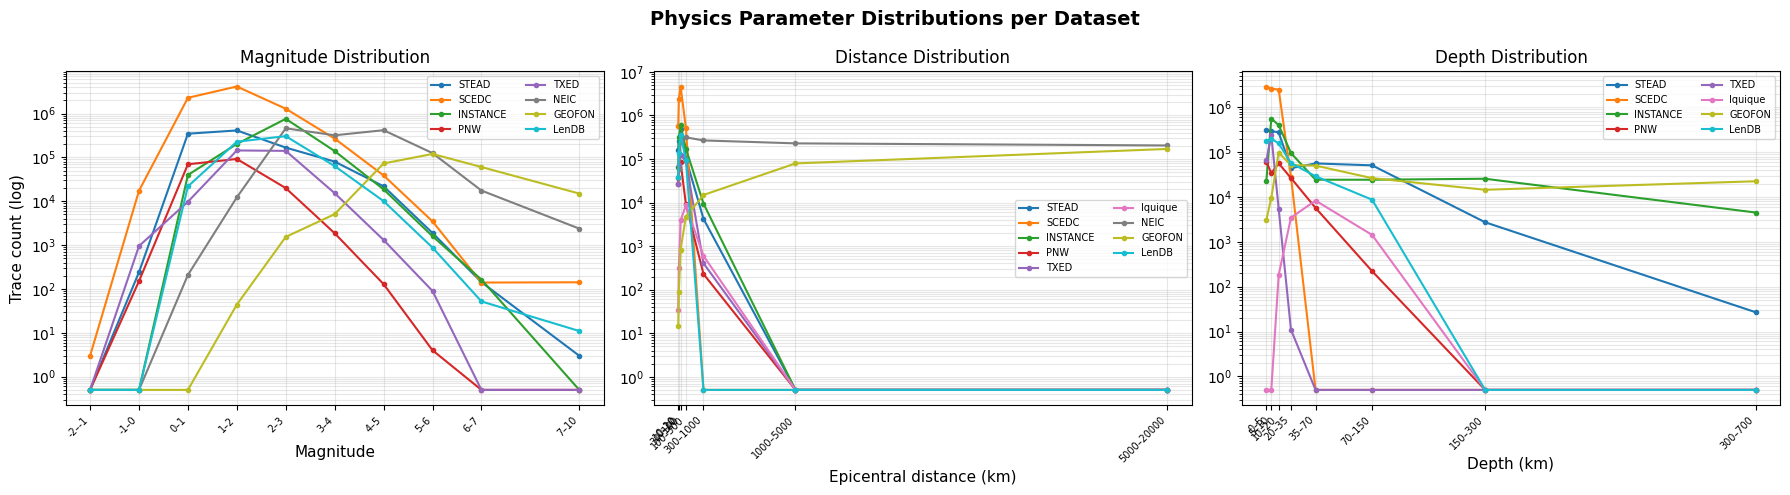

Saved → physics_distributions.png


In [9]:
# ── 1.4 — Physics Parameter Distribution Plots ─────────────────────────────
# Visualise the magnitude, distance, and depth distributions across all
# datasets so coverage gaps are immediately visible.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

DS_ORDER = ['stead', 'scedc', 'instancecounts', 'pnw', 'txed',
            'obst2024', 'iquique', 'neic', 'geofon', 'lendb']
DS_LABELS = ['STEAD', 'SCEDC', 'INSTANCE', 'PNW', 'TXED',
             'OBST2024', 'Iquique', 'NEIC', 'GEOFON', 'LenDB']
COLORS = plt.cm.tab10.colors

# Bin-centre helpers
def centres(edges): return [(edges[i]+edges[i+1])/2 for i in range(len(edges)-1)]
mag_centres   = centres(mag_bins)
depth_centres = centres(depth_bins)
dist_centres  = centres(dist_bins)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Physics Parameter Distributions per Dataset', fontsize=14, fontweight='bold')

ax_mag, ax_dist, ax_depth = axes

for idx, (ds, label) in enumerate(zip(DS_ORDER, DS_LABELS)):
    if ds not in results:
        continue
    r = results[ds]
    color = COLORS[idx % len(COLORS)]

    # Magnitude
    if any(v > 0 for v in r['mag']):
        ax_mag.semilogy(mag_centres, [max(v, 0.5) for v in r['mag']],
                        marker='o', ms=3, lw=1.5, label=label, color=color)

    # Distance
    if any(v > 0 for v in r['dist']):
        ax_dist.semilogy(dist_centres, [max(v, 0.5) for v in r['dist']],
                         marker='o', ms=3, lw=1.5, label=label, color=color)

    # Depth
    if any(v > 0 for v in r['depth']):
        ax_depth.semilogy(depth_centres, [max(v, 0.5) for v in r['depth']],
                          marker='o', ms=3, lw=1.5, label=label, color=color)

# Format axes
ax_mag.set_xlabel('Magnitude', fontsize=11)
ax_mag.set_ylabel('Trace count (log)', fontsize=11)
ax_mag.set_title('Magnitude Distribution')
ax_mag.set_xticks(mag_centres)
ax_mag.set_xticklabels([f'{b}–{mag_bins[i+1]}' for i, b in enumerate(mag_bins[:-1])],
                        rotation=45, ha='right', fontsize=7)
ax_mag.legend(fontsize=7, ncol=2)

ax_dist.set_xlabel('Epicentral distance (km)', fontsize=11)
ax_dist.set_title('Distance Distribution')
ax_dist.set_xticks(dist_centres)
ax_dist.set_xticklabels([f'{b}–{dist_bins[i+1]}' for i, b in enumerate(dist_bins[:-1])],
                         rotation=45, ha='right', fontsize=7)
ax_dist.legend(fontsize=7, ncol=2)

ax_depth.set_xlabel('Depth (km)', fontsize=11)
ax_depth.set_title('Depth Distribution')
ax_depth.set_xticks(depth_centres)
ax_depth.set_xticklabels([f'{b}–{depth_bins[i+1]}' for i, b in enumerate(depth_bins[:-1])],
                          rotation=45, ha='right', fontsize=7)
ax_depth.legend(fontsize=7, ncol=2)

for ax in axes:
    ax.grid(True, which='both', alpha=0.3)
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

plt.tight_layout()
plt.savefig('physics_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → physics_distributions.png')


stead               :  1,030,231 valid S-P pairs
scedc               :  3,781,792 valid S-P pairs
instancecounts      :    713,875 valid S-P pairs
pnw                 :    183,909 valid S-P pairs
txed                :    312,224 valid S-P pairs
obst2024            :     35,384 valid S-P pairs
iquique             :     11,288 valid S-P pairs
neic                :          0 valid S-P pairs


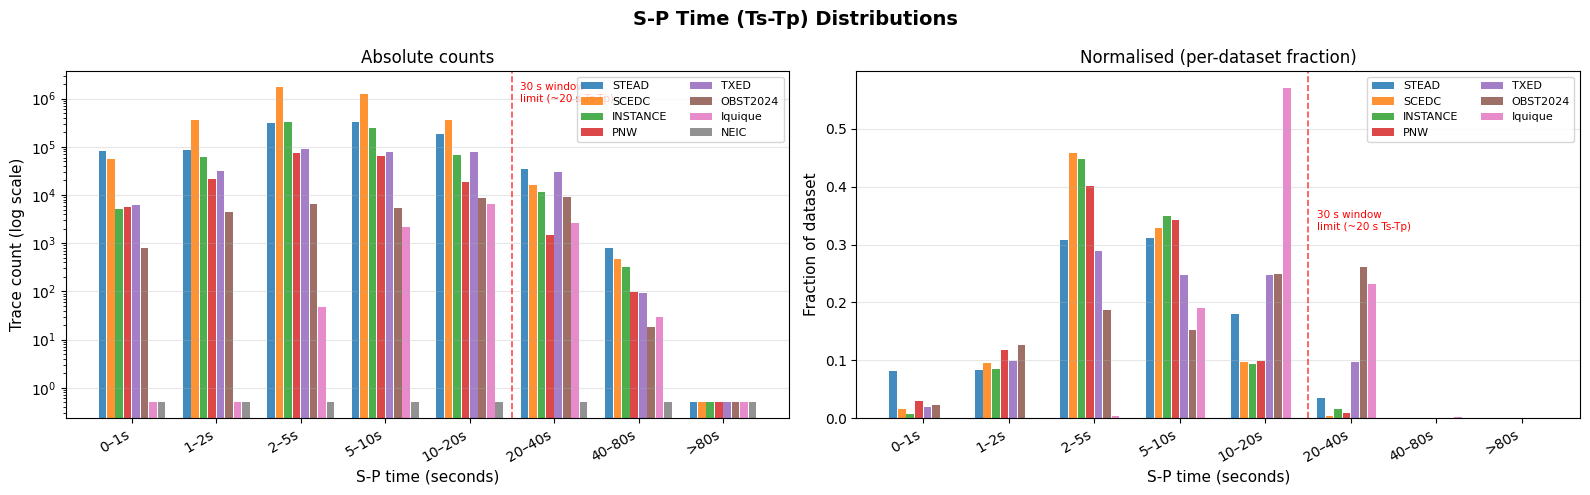

Saved → sp_time_distributions.png

Dataset               median Ts-Tp   % within 20s    % >20s
------------------------------------------------------------
STEAD                        5–10s          96.5%      3.5%
SCEDC                         2–5s          99.6%      0.4%
INSTANCE                      2–5s          98.3%      1.7%
PNW                           2–5s          99.1%      0.9%
TXED                         5–10s          90.3%      9.7%
OBST2024                    10–20s          73.8%     26.2%
Iquique                     10–20s          76.5%     23.5%


In [10]:
# ── 1.4b — S-P Time (Ts-Tp) Distributions ──────────────────────────────────
# Ts-Tp = (S_arrival_sample - P_arrival_sample) / sampling_rate
# This is a direct proxy for epicentral distance AND is the quantity that
# determines how well-separated P and S are in the picker's input window.
# Datasets with no S picks (lendb) or very few (geofon, neic) are skipped.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from pathlib import Path

# ── Dataset config: p_col, s_col, sr_col (None = default 100 Hz) ────────────
SP_DATASETS = {
    'stead':          {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': None},
    'scedc':          {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': 'trace_sampling_rate_hz'},
    'instancecounts': {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',  'sr': None},
    'pnw':            {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',  'sr': 'trace_sampling_rate_hz'},
    'txed':           {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': None},
    'obst2024':       {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': 'trace_sampling_rate_hz'},
    'iquique':        {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',  'sr': 'trace_sampling_rate_hz'},
    'neic':           {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': None},
    # geofon and lendb excluded: <1% and 0% S picks respectively
}

# ── Bin edges and labels ─────────────────────────────────────────────────────
SP_EDGES  = [0, 1, 2, 5, 10, 20, 40, 80, 200]
SP_LABELS = ['0–1s', '1–2s', '2–5s', '5–10s', '10–20s', '20–40s', '40–80s', '>80s']
DEFAULT_SR = 100.0

sp_results = {}   # ds_name → np.array of counts per bin

for ds_name, cfg in SP_DATASETS.items():
    meta_path = CACHE / ds_name / 'metadata.csv'
    if not meta_path.exists():
        print(f'SKIP {ds_name}: no metadata.csv')
        continue

    # Decide which columns to load
    all_cols = set(pd.read_csv(meta_path, nrows=0).columns)
    usecols  = [c for c in [cfg['p'], cfg['s'], cfg['sr']] if c and c in all_cols]
    missing  = [c for c in [cfg['p'], cfg['s']] if c not in all_cols]
    if missing:
        print(f'SKIP {ds_name}: missing columns {missing}')
        continue

    counts = np.zeros(len(SP_EDGES) - 1, dtype=np.int64)
    n_valid = 0

    for chunk in pd.read_csv(meta_path, usecols=usecols, chunksize=200_000, low_memory=False):
        mask = chunk[cfg['p']].notna() & chunk[cfg['s']].notna()
        chunk = chunk[mask]
        if len(chunk) == 0:
            continue

        if cfg['sr'] and cfg['sr'] in chunk.columns:
            sr = chunk[cfg['sr']].fillna(DEFAULT_SR).clip(lower=1).values
        else:
            sr = np.full(len(chunk), DEFAULT_SR)

        sp = (chunk[cfg['s']].values - chunk[cfg['p']].values) / sr
        sp = sp[np.isfinite(sp) & (sp > 0)]   # keep only positive, finite values
        counts += np.histogram(sp, bins=SP_EDGES)[0]
        n_valid += len(sp)

    sp_results[ds_name] = counts
    print(f'{ds_name:20s}: {n_valid:>10,} valid S-P pairs')

# ── Plot 1: S-P distribution per dataset (log-scale bar chart) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('S-P Time (Ts-Tp) Distributions', fontsize=14, fontweight='bold')

ax_log, ax_frac = axes
x     = np.arange(len(SP_LABELS))
width = 0.8 / len(sp_results)
COLORS = plt.cm.tab10.colors

DS_DISPLAY = {'stead':'STEAD','scedc':'SCEDC','instancecounts':'INSTANCE',
              'pnw':'PNW','txed':'TXED','obst2024':'OBST2024',
              'iquique':'Iquique','neic':'NEIC'}

for idx, (ds, counts) in enumerate(sp_results.items()):
    offset = (idx - len(sp_results)/2 + 0.5) * width
    label  = DS_DISPLAY.get(ds, ds)
    color  = COLORS[idx % len(COLORS)]

    # Left panel: absolute counts (log)
    ax_log.bar(x + offset, np.maximum(counts, 0.5), width=width*0.9,
               label=label, color=color, alpha=0.85)

    # Right panel: normalised (fraction of dataset)
    total = counts.sum()
    if total > 0:
        ax_frac.bar(x + offset, counts / total, width=width*0.9,
                    label=label, color=color, alpha=0.85)

ax_log.set_yscale('log')
ax_log.set_ylabel('Trace count (log scale)', fontsize=11)
ax_log.set_title('Absolute counts')
ax_frac.set_ylabel('Fraction of dataset', fontsize=11)
ax_frac.set_title('Normalised (per-dataset fraction)')

for ax in axes:
    ax.set_xlabel('S-P time (seconds)', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(SP_LABELS, rotation=30, ha='right')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, axis='y', alpha=0.3)

# Annotate the picker window constraint
# PhaseNet uses a 30 s window at 100 Hz → max Ts-Tp before S exits window ≈ ~20 s
for ax in axes:
    ax.axvline(x=SP_LABELS.index('10–20s') + 0.5, color='red',
               linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(SP_LABELS.index('10–20s') + 0.6, ax.get_ylim()[1]*0.6,
            '30 s window\nlimit (~20 s Ts-Tp)', color='red', fontsize=7.5, va='top')

plt.tight_layout()
plt.savefig('sp_time_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → sp_time_distributions.png')

# ── Quick summary table ──────────────────────────────────────────────────────
print(f"\n{'Dataset':20s}  {'median Ts-Tp':>12s}  {'% within 20s':>13s}  {'% >20s':>8s}")
print('-' * 60)
for ds, counts in sp_results.items():
    total = counts.sum()
    if total == 0: continue
    # Approximate median bin
    cumsum = np.cumsum(counts)
    median_bin = SP_LABELS[np.searchsorted(cumsum, total/2)]
    within_20 = counts[:5].sum() / total * 100   # bins 0-20s (first 5 bins)
    beyond_20 = counts[5:].sum() / total * 100
    print(f"{DS_DISPLAY.get(ds, ds):20s}  {median_bin:>12s}  {within_20:>12.1f}%  {beyond_20:>7.1f}%")


### Key observations from distributions

- **Magnitude < 1:** Dominated by SCEDC (2.3M traces). Without SCEDC, small events are severely underrepresented.
- **Depth > 70 km:** Comes almost entirely from INSTANCE, GEOFON, and STEAD. Deep events are rare overall.
- **Distance > 1500 km:** NEIC + GEOFON only. Teleseismic coverage depends on two datasets.
- **GEOFON is primarily teleseismic:** 170K traces at >5000 km distance. This was not obvious from its description.
- **OBST2024:** All physics columns are NaN despite column names existing — unusable for stratification.
- **⚠ Teleseismic gap in benchmark:** NEIC lacks depth metadata and GEOFON has <1% S picks, so neither can enter the physics-bin stratification. The final benchmark contains **0 teleseismic traces** (>1,500 km). This is a known limitation: the `neic` and `geofon` model weights cannot be fairly evaluated on their primary use case. Consider adding a dedicated flat teleseismic hold-out in a future step.


<a id='1.4b'></a>
## 1.4b Label Quality Filtering

Alberto Ardid (labelerrors, 2024) identified pervasive label errors in several SeisBench
datasets using confident learning — traces where a trained model is consistently more
confident in a different pick than the one assigned. Clean datasets outperform larger
noisy ones; these traces must be excluded from **both** benchmark testing and future
training.

Join key: `trace_name` (standard SeisBench unique identifier).

| Report file          | Maps to dataset   | Bad traces |
|----------------------|-------------------|------------|
| stead_report.csv     | stead             | 149        |
| instance_report.csv  | instancecounts    | **92,561** |
| pnw_report.csv       | pnw               | 4,970      |
| txed_report.csv      | txed              | 4,672      |
| iquique_report.csv   | iquique           | 515        |
| ethz_report.csv      | ethz (not in benchmark) | 895  |

Not yet analyzed by Ardid: scedc, neic, geofon, lendb, obst2024.

In [11]:
from pathlib import Path
import pandas as pd

# ── UPDATE this path to wherever you saved the Alberto Ardid CSVs ──
LABEL_ERROR_DIR = Path('../data/labelerrors/')

REPORT_MAP = {
    'stead_report':    'stead',
    'instance_report': 'instancecounts',   # SeisBench name differs from report stem
    'pnw_report':      'pnw',
    'txed_report':     'txed',
    'iquique_report':  'iquique',
    'ethz_report':     'ethz',
}

bad_traces = {}   # ds_name  →  set of bad trace_name strings

for stem, ds_name in REPORT_MAP.items():
    fpath = LABEL_ERROR_DIR / f'{stem}.csv'
    if not fpath.exists():
        print(f'MISSING  {fpath}')
        continue
    df_bad = pd.read_csv(fpath, usecols=['trace_name'])
    bad_traces[ds_name] = set(df_bad['trace_name'])
    print(f'{ds_name:20s}  bad traces flagged: {len(bad_traces[ds_name]):>7,}')

print(f'\nTotal bad traces across all datasets: {sum(len(v) for v in bad_traces.values()):,}')
print('No report available for: scedc, neic, geofon, lendb, obst2024')

stead                 bad traces flagged:     149
instancecounts        bad traces flagged:  92,561
pnw                   bad traces flagged:   4,970
txed                  bad traces flagged:   4,672
iquique               bad traces flagged:     515
ethz                  bad traces flagged:     895

Total bad traces across all datasets: 103,762
No report available for: scedc, neic, geofon, lendb, obst2024


<a id='1.5'></a>
## 1.5 Benchmark Construction

Build a physics-stratified benchmark with seismologically motivated bins.

### Design decisions (incorporating advisor feedback)

| Decision | Rationale |
|---|---|
| **Require both P and S** | A picker that cannot pick S is not a general picker |
| **Exclude Ardid bad labels** | Mislabeled test traces penalise correct model predictions |
| **Ts–Tp as stratification axis** | More physically meaningful than distance alone: directly sets the P–S separation in the waveform window |
| **G-R weighted within-bin sampling** | Seismicity follows log₁₀N = a − bM (b≈1); flat sampling would oversample large events |
| **Tectonic type tag** | Enables post-hoc breakdown by mechanism proxy |

### Physics bins

| Axis | Bins |
|---|---|
| **Distance** | local <150 km · regional 150–1500 km · teleseismic >1500 km |
| **Depth** | 0–15 · 15–70 · 70–300 · >300 km |
| **Magnitude** | M < 3 · M 3–6 · M > 6 |
| **Ts–Tp** | computed and stored; used as diagnostic, not a sampling axis |

3 × 4 × 3 = 36 physics bins · target 150 traces/bin · cap 80 traces/dataset/bin

Datasets dropped from full 3-axis pool (no S picks): **geofon** (~1% S), **lendb** (P-only).
Special handling: NEIC (no depth) → distance × magnitude; Iquique (no mag) → distance × depth;
OBST2024 (no physics metadata) → flat 400-trace sample.

In [12]:
def safe_usecols(meta_path, wanted):
    """Return only columns from `wanted` that exist in the CSV header."""
    existing = set(pd.read_csv(meta_path, nrows=0).columns)
    return [c for c in wanted if c in existing]


# ============================================================
# 1.5  Benchmark Construction  —  clean master script
# Run this cell to produce benchmark_manifest.csv
# Prerequisites: CACHE defined (Cell 1), haversine_km defined (Cell 13),
#               bad_traces dict defined (Cell 1.4b)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ── Configuration ─────────────────────────────────────────
TARGET_PER_BIN          = 150
MAX_PER_DATASET_PER_BIN = 80
OBST2024_FLAT_SAMPLE    = 400
NEIC_TARGET_PER_BIN     = 150
IQUIQUE_TARGET_PER_BIN  = 80
NEIC_TELESEISMIC_TOTAL  = 1350  # ~equal to local + regional strata
RANDOM_SEED             = 42
GR_B_VALUE              = 1.0   # Gutenberg-Richter b-value for within-bin weighting

DIST_EDGES  = [0,   150,  1500, np.inf]
DIST_LABELS = ['local (<150km)', 'regional (150-1500km)', 'teleseismic (>1500km)']

DEPTH_EDGES  = [0,  15,  70,  300, np.inf]
DEPTH_LABELS = ['upper-crustal (0-15km)', 'lower-crust (15-70km)',
                'intermediate (70-300km)', 'deep-focus (>300km)']

MAG_EDGES  = [-np.inf, 3.0, 6.0, np.inf]
MAG_LABELS = ['micro (M<3)', 'moderate (M3-6)', 'large (M>6)']

# ── Dataset configurations ────────────────────────────────
# geofon and lendb removed: <1% and 0% S picks respectively.
# Requiring both P and S would leave essentially nothing.
FULL_DATASETS = {
    'stead': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'source_distance_km',
        'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': False, 'tectonic_type': 'global_mixed',
        'region': 'Global (US-heavy)', 'trained_models': ['stead'],
    },
    'scedc': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'station_epicentral_distance',
        'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': False, 'tectonic_type': 'transform',
        'region': 'Southern California', 'trained_models': ['scedc'],
    },
    'instancecounts': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'path_ep_distance_km',
        'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': False, 'tectonic_type': 'subduction_crustal',
        'region': 'Italy / Mediterranean', 'trained_models': ['instance'],
    },
    'pnw': {
        'mag': 'preferred_source_magnitude', 'depth': 'source_depth_km', 'dist': None,
        'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': True, 'tectonic_type': 'subduction',
        'region': 'Pacific Northwest / Cascadia', 'trained_models': [],
    },
    'txed': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': None,
        'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': True, 'tectonic_type': 'induced',
        'region': 'Texas (induced seismicity)', 'trained_models': [],
    },
}

# ── Helper functions ──────────────────────────────────────

def assign_bins(series, edges, labels):
    return pd.cut(series, bins=edges, labels=labels, right=False, include_lowest=True)

def gr_weight(magnitude_series, b=GR_B_VALUE):
    """
    Gutenberg-Richter inverse weight: 10^(-b*M).
    Smaller-magnitude events are proportionally more common in nature;
    this weight corrects for flat sampling within a magnitude bin.
    Weights are normalised to sum to 1 within each call.
    """
    w = np.power(10.0, -b * magnitude_series.values)
    w = np.where(np.isfinite(w), w, 1.0)
    return w / w.sum()

def load_and_filter(meta_path, usecols, p_col, s_col, bad_set,
                    chunksize=500_000, require_s=True):
    """
    Load metadata CSV in chunks, keeping only traces that:
      - have a valid P pick
      - have a valid S pick  (if require_s=True; set False for P-only datasets like NEIC)
      - are not in Alberto's bad set  (label quality filter)
    Returns a concatenated DataFrame, or None if nothing survives.
    """
    chunks = []
    for chunk in pd.read_csv(meta_path, usecols=usecols, chunksize=chunksize, low_memory=False):
        # Require P; optionally require S
        mask = chunk[p_col].notna()
        if require_s and s_col in chunk.columns:
            mask = mask & chunk[s_col].notna()
        chunk = chunk[mask]
        # Exclude Alberto Ardid bad labels
        if bad_set and 'trace_name' in chunk.columns:
            n_before = len(chunk)
            chunk = chunk[~chunk['trace_name'].isin(bad_set)]
            if n_before - len(chunk) > 0:
                pass  # tally is printed after loop
        if len(chunk) > 0:
            chunks.append(chunk)
    return pd.concat(chunks, ignore_index=False) if chunks else None


# ── Process FULL_DATASETS ─────────────────────────────────
full_traces = []

for ds_name, cfg in FULL_DATASETS.items():
    meta_path = CACHE / ds_name / 'metadata.csv'
    if not meta_path.exists():
        print(f'SKIP {ds_name}: no metadata.csv')
        continue

    # Build usecols list
    # Check which optional columns actually exist in this metadata file
    all_cols = set(pd.read_csv(meta_path, nrows=0).columns)
    sr_col = cfg['sr'] if cfg['sr'] in all_cols else None
    usecols = ['trace_name', cfg['p'], cfg['s'], cfg['mag'], cfg['depth']]
    if sr_col:
        usecols.append(sr_col)
    if cfg['dist']:
        usecols.append(cfg['dist'])
    if cfg['compute_dist']:
        usecols += ['source_latitude_deg', 'source_longitude_deg',
                    'station_latitude_deg', 'station_longitude_deg']
    usecols = list(dict.fromkeys(usecols))   # deduplicate, preserve order

    print(f'Reading {ds_name}...', end=' ', flush=True)
    raw = load_and_filter(
        meta_path, usecols,
        p_col   = cfg['p'],
        s_col   = cfg['s'],
        bad_set = bad_traces.get(ds_name, set()),
    )
    if raw is None:
        print('no valid traces after filtering'); continue

    n_raw   = len(raw)
    n_bad   = len(bad_traces.get(ds_name, set()))

    # ── Build output DataFrame ──
    out = pd.DataFrame()
    out['trace_name']       = raw['trace_name'].values
    out['original_index']   = raw.index.values
    out['magnitude']        = raw[cfg['mag']].values
    out['depth_km']         = raw[cfg['depth']].values
    out['p_arrival_sample'] = raw[cfg['p']].values
    out['s_arrival_sample'] = raw[cfg['s']].values
    out['has_s_pick']       = True   # guaranteed by load_and_filter

    # Distance
    if cfg['compute_dist']:
        out['distance_km'] = haversine_km(
            raw['source_latitude_deg'].values, raw['source_longitude_deg'].values,
            raw['station_latitude_deg'].values, raw['station_longitude_deg'].values,
        )
    else:
        out['distance_km'] = raw[cfg['dist']].values

    # Ts-Tp in seconds  (advisor request: more physically meaningful than distance alone)
    if sr_col and sr_col in raw.columns:
        sr = raw[sr_col].values
    else:
        sr = np.full(len(raw), 100.0)   # default: 100 Hz (standard for most SeisBench datasets)
        print(f'  [{ds_name}] trace_sampling_rate_hz not found — defaulting to 100 Hz for Ts-Tp')
    out['ts_tp_s'] = np.where(
        (sr > 0) & np.isfinite(sr),
        (out['s_arrival_sample'].values - out['p_arrival_sample'].values) / sr,
        np.nan,
    )

    # G-R sampling weight  (advisor request: correct for power-law magnitude distribution)
    out['gr_weight'] = np.where(
        out['magnitude'].notna(),
        np.power(10.0, -GR_B_VALUE * out['magnitude'].values),
        1.0,
    )

    # Physics bins
    out['dist_bin']  = assign_bins(out['distance_km'], DIST_EDGES, DIST_LABELS)
    out['depth_bin'] = assign_bins(out['depth_km'],    DEPTH_EDGES, DEPTH_LABELS)
    out['mag_bin']   = assign_bins(out['magnitude'],   MAG_EDGES,   MAG_LABELS)

    fully_binned = out['dist_bin'].notna() & out['depth_bin'].notna() & out['mag_bin'].notna()
    out['physics_bin'] = np.where(
        fully_binned,
        out['dist_bin'].astype(str) + ' | ' + out['depth_bin'].astype(str) + ' | ' + out['mag_bin'].astype(str),
        'partial',
    )

    # Metadata
    out['dataset']       = ds_name
    out['tectonic_type'] = cfg['tectonic_type']
    out['region']        = cfg['region']
    out['trained_models']= ','.join(cfg['trained_models'])

    n_binned = fully_binned.sum()
    print(f'{n_raw:,} kept (of those, {n_bad:,} bad labels excluded) | {n_binned:,} fully binned')
    full_traces.append(out[fully_binned])


# ── Process NEIC (teleseismic only, P-only filter) ───────
# NEIC has 0 traces with both P+S on the same waveform (picks are stored
# on separate per-phase trace records). We relax the S requirement here
# and record has_s_pick per trace. Only teleseismic traces (>1500 km) are
# kept — local/regional NEIC traces overlap with existing datasets.
# NOTE: NEIC waveforms are at 40 Hz; resample to 100 Hz before inference.
print('\nReading neic...', end=' ', flush=True)
neic_path   = CACHE / 'neic' / 'metadata.csv'
neic_traces = None
if neic_path.exists():
    neic_usecols = safe_usecols(neic_path, ['trace_name', 'trace_p_arrival_sample',
                    'trace_s_arrival_sample', 'source_magnitude',
                    'path_ep_distance_km', 'trace_sampling_rate_hz'])
    raw = load_and_filter(neic_path, neic_usecols,
                          p_col='trace_p_arrival_sample',
                          s_col='trace_s_arrival_sample',
                          bad_set=bad_traces.get('neic', set()),
                          require_s=False)          # ← P-only
    if raw is not None:
        out = pd.DataFrame()
        out['trace_name']       = raw['trace_name'].values
        out['original_index']   = raw.index.values
        out['magnitude']        = raw['source_magnitude'].values
        out['depth_km']         = np.nan          # not available in NEIC
        out['distance_km']      = raw['path_ep_distance_km'].values
        out['p_arrival_sample'] = raw['trace_p_arrival_sample'].values

        # S arrival: present on some traces (store NaN where absent)
        if 'trace_s_arrival_sample' in raw.columns:
            out['s_arrival_sample'] = raw['trace_s_arrival_sample'].values
        else:
            out['s_arrival_sample'] = np.nan

        # has_s_pick: True only where S sample is actually recorded
        out['has_s_pick'] = out['s_arrival_sample'].notna()

        # ts_tp_s: only computable where S exists
        sr = (raw['trace_sampling_rate_hz'].values
              if 'trace_sampling_rate_hz' in raw.columns
              else np.full(len(raw), 40.0))   # NEIC native rate is 40 Hz
        out['ts_tp_s'] = np.where(
            out['has_s_pick'] & (sr > 0) & np.isfinite(sr),
            (out['s_arrival_sample'].values - out['p_arrival_sample'].values) / sr,
            np.nan)

        out['gr_weight']    = np.power(10.0, -GR_B_VALUE * out['magnitude'].fillna(0).values)
        out['dist_bin']     = assign_bins(out['distance_km'], DIST_EDGES, DIST_LABELS)
        out['depth_bin']    = np.nan
        out['mag_bin']      = assign_bins(out['magnitude'], MAG_EDGES, MAG_LABELS)

        # Keep ONLY teleseismic traces (local/regional already covered by other datasets)
        teleseismic_mask = out['dist_bin'] == 'teleseismic (>1500km)'
        valid = teleseismic_mask & out['mag_bin'].notna()

        out['physics_bin'] = np.where(
            valid,
            'teleseismic (>1500km) | depth_unknown | ' + out['mag_bin'].astype(str),
            'unusable')
        out['dataset']       = 'neic'
        out['tectonic_type'] = 'global_teleseismic'
        out['region']        = 'Global (teleseismic)'
        out['trained_models']= 'neic'
        neic_traces = out[valid].copy()
        n_with_s = neic_traces['has_s_pick'].sum()
        print(f'{len(raw):,} loaded (P-only) | {valid.sum():,} teleseismic '
              f'| {n_with_s:,} also have S ({100*n_with_s/valid.sum():.1f}%)')


# ── Process Iquique (distance × depth, no magnitude) ─────
print('Reading iquique...', end=' ', flush=True)
iq_path   = CACHE / 'iquique' / 'metadata.csv'
iq_traces = None
if iq_path.exists():
    iq_usecols = safe_usecols(iq_path, ['trace_name', 'trace_P_arrival_sample', 'trace_S_arrival_sample',
                  'source_depth_km', 'trace_sampling_rate_hz',
                  'source_latitude_deg', 'source_longitude_deg',
                  'station_latitude_deg', 'station_longitude_deg'])
    raw = load_and_filter(iq_path, iq_usecols,
                          'trace_P_arrival_sample', 'trace_S_arrival_sample',
                          bad_set=bad_traces.get('iquique', set()))
    if raw is not None:
        out = pd.DataFrame()
        out['trace_name']       = raw['trace_name'].values
        out['original_index']   = raw.index.values
        out['magnitude']        = np.nan          # not available in Iquique
        out['depth_km']         = raw['source_depth_km'].values
        out['distance_km']      = haversine_km(
            raw['source_latitude_deg'].values, raw['source_longitude_deg'].values,
            raw['station_latitude_deg'].values, raw['station_longitude_deg'].values)
        out['p_arrival_sample'] = raw['trace_P_arrival_sample'].values
        out['s_arrival_sample'] = raw['trace_S_arrival_sample'].values
        out['has_s_pick']       = True
        sr = raw['trace_sampling_rate_hz'].values if 'trace_sampling_rate_hz' in raw.columns else np.full(len(raw), 100.0)
        out['ts_tp_s'] = np.where((sr > 0) & np.isfinite(sr),
                                  (out['s_arrival_sample'].values - out['p_arrival_sample'].values) / sr, np.nan)
        out['gr_weight']    = 1.0      # no magnitude → flat weight
        out['dist_bin']     = assign_bins(out['distance_km'], DIST_EDGES, DIST_LABELS)
        out['depth_bin']    = assign_bins(out['depth_km'],    DEPTH_EDGES, DEPTH_LABELS)
        out['mag_bin']      = np.nan
        valid = out['dist_bin'].notna() & out['depth_bin'].notna()
        out['physics_bin']  = np.where(valid,
            out['dist_bin'].astype(str) + ' | ' + out['depth_bin'].astype(str) + ' | mag_unknown', 'unusable')
        out['dataset']       = 'iquique'
        out['tectonic_type'] = 'subduction_aftershock'
        out['region']        = 'Northern Chile'
        out['trained_models']= 'iquique'
        iq_traces = out[valid]
        print(f'{len(raw):,} kept | {valid.sum():,} binned (dist × depth, no mag)')


# ── Process OBST2024 (flat sample, no physics metadata) ──
print('Reading obst2024...', end=' ', flush=True)
obst_path   = CACHE / 'obst2024' / 'metadata.csv'
obst_traces = None
if obst_path.exists():
    obs_usecols = safe_usecols(obst_path, ['trace_name', 'trace_p_arrival_sample', 'trace_s_arrival_sample',
                   'trace_sampling_rate_hz'])
    raw = load_and_filter(
        obst_path, obs_usecols,
        p_col='trace_p_arrival_sample', s_col='trace_s_arrival_sample',
        bad_set=bad_traces.get('obst2024', set()))
    if raw is not None:
        out = pd.DataFrame()
        out['trace_name']       = raw['trace_name'].values
        out['original_index']   = raw.index.values
        for col in ['magnitude', 'depth_km', 'distance_km']: out[col] = np.nan
        out['p_arrival_sample'] = raw['trace_p_arrival_sample'].values
        out['s_arrival_sample'] = raw['trace_s_arrival_sample'].values
        out['has_s_pick']       = True
        sr = raw['trace_sampling_rate_hz'].values if 'trace_sampling_rate_hz' in raw.columns else np.full(len(raw), 100.0)
        out['ts_tp_s'] = np.where((sr > 0) & np.isfinite(sr),
                                  (out['s_arrival_sample'].values - out['p_arrival_sample'].values) / sr, np.nan)
        out['gr_weight']     = 1.0
        for col in ['dist_bin', 'depth_bin', 'mag_bin']: out[col] = np.nan
        out['physics_bin']   = 'OBS_flat'
        out['dataset']       = 'obst2024'
        out['tectonic_type'] = 'ocean_bottom'
        out['region']        = 'East Pacific Rise (OBS)'
        out['trained_models']= 'obs'
        obst_traces = out
        print(f'{len(out):,} valid traces (flat sample, no physics binning)')


Reading stead...   [stead] trace_sampling_rate_hz not found — defaulting to 100 Hz for Ts-Tp
1,030,082 kept (of those, 149 bad labels excluded) | 1,023,138 fully binned
Reading scedc... 3,783,102 kept (of those, 0 bad labels excluded) | 3,727,167 fully binned
Reading instancecounts...   [instancecounts] trace_sampling_rate_hz not found — defaulting to 100 Hz for Ts-Tp
631,167 kept (of those, 92,561 bad labels excluded) | 631,167 fully binned
Reading pnw... 178,939 kept (of those, 4,970 bad labels excluded) | 154,552 fully binned
Reading txed...   [txed] trace_sampling_rate_hz not found — defaulting to 100 Hz for Ts-Tp
307,559 kept (of those, 4,672 bad labels excluded) | 307,219 fully binned

Reading neic... 1,025,000 loaded (P-only) | 391,357 teleseismic | 0 also have S (0.0%)
Reading iquique... 10,798 kept | 10,798 binned (dist × depth, no mag)
Reading obst2024... 35,394 valid traces (flat sample, no physics binning)


In [13]:
# ── Stratified sampling with Gutenberg-Richter weighting ──
#
# Within each physics bin we sample proportionally to 10^(-b*M) (G-R, b=1).
# This corrects for flat sampling overrepresenting large events:
# nature has ~10x more M2 events than M3, ~100x more M1 than M3, etc.
# For bins where magnitude is unavailable (Iquique, OBST2024) we use flat weights.

rng     = np.random.RandomState(RANDOM_SEED)
sampled = []

# A. Full 3-axis bins
if full_traces:
    full_pool = pd.concat(full_traces, ignore_index=True)
    for bin_name, group in full_pool.groupby('physics_bin'):
        bin_samples = []
        for ds_name, ds_group in group.groupby('dataset'):
            n = min(MAX_PER_DATASET_PER_BIN, len(ds_group))
            # G-R weighted sampling within this dataset × bin slice
            w = ds_group['gr_weight'].values
            w = w / w.sum()
            bin_samples.append(ds_group.sample(n=n, weights=w, random_state=rng))
        bin_df = pd.concat(bin_samples)
        if len(bin_df) > TARGET_PER_BIN:
            # G-R weighted final draw across datasets
            w = bin_df['gr_weight'].values
            w = w / w.sum()
            bin_df = bin_df.sample(n=TARGET_PER_BIN, weights=w, random_state=rng)
        sampled.append(bin_df)
    print(f"Full 3-axis bins: {sum(len(s) for s in sampled):,} traces")

# B. NEIC teleseismic — flat target across all teleseismic mag bins combined
# Target ~equal representation to local and regional strata.
# G-R weighted sampling so large events are not overrepresented.
if neic_traces is not None:
    n_neic = min(NEIC_TELESEISMIC_TOTAL, len(neic_traces))
    w = neic_traces['gr_weight'].values
    w = w / w.sum()
    neic_sample = neic_traces.sample(n=n_neic, weights=w, random_state=rng)
    sampled.append(neic_sample)
    n_with_s = neic_sample['has_s_pick'].sum()
    print(f"NEIC teleseismic: {n_neic:,} traces "
          f"({n_with_s:,} with S pick, {n_neic - n_with_s:,} P-only)")

# C. Iquique (distance × depth)
if iq_traces is not None:
    iq_count = 0
    for bin_name, group in iq_traces.groupby('physics_bin'):
        n = min(IQUIQUE_TARGET_PER_BIN, len(group))
        sampled.append(group.sample(n=n, random_state=rng))   # flat: no magnitude
        iq_count += n
    print(f"Iquique: {iq_count:,} traces across {iq_traces['physics_bin'].nunique()} bins")

# D. OBST2024 (flat)
if obst_traces is not None:
    n_obs = min(OBST2024_FLAT_SAMPLE, len(obst_traces))
    sampled.append(obst_traces.sample(n=n_obs, random_state=rng))
    print(f"OBST2024: {n_obs:,} traces")

benchmark = pd.concat(sampled, ignore_index=True)
print(f"\nTotal benchmark: {len(benchmark):,} traces")
print(f"  with S pick:     {benchmark['has_s_pick'].sum():,}")
print(f"  with Ts-Tp:      {benchmark['ts_tp_s'].notna().sum():,}")


Full 3-axis bins: 2,406 traces
NEIC teleseismic: 1,350 traces (0 with S pick, 1,350 P-only)
Iquique: 320 traces across 4 bins
OBST2024: 400 traces

Total benchmark: 4,476 traces
  with S pick:     3,126
  with Ts-Tp:      3,126


/tmp/ipykernel_78556/1985245909.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  benchmark = pd.concat(sampled, ignore_index=True)
/tmp/ipykernel_78556/1985245909.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  benchmark = pd.concat(sampled, ignore_index=True)
/tmp/ipykernel_78556/1985245909.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining th

In [14]:
# Save benchmark manifest
output_cols = [
    'dataset', 'trace_name', 'original_index',
    'tectonic_type', 'region', 'trained_models',
    'magnitude', 'depth_km', 'distance_km', 'ts_tp_s',
    'p_arrival_sample', 's_arrival_sample', 'has_s_pick',
    'dist_bin', 'depth_bin', 'mag_bin', 'physics_bin',
]
benchmark[output_cols].to_csv('benchmark_manifest.csv', index=False)
print(f"Saved benchmark_manifest.csv  ({len(benchmark):,} traces)")


Saved benchmark_manifest.csv  (4,476 traces)


<a id='1.6'></a>
## 1.6 Benchmark Summary

In [15]:
print(f"Total traces: {len(benchmark):,}")
print(f"All have S pick: {benchmark['has_s_pick'].all()}")
print(f"Ts-Tp available: {benchmark['ts_tp_s'].notna().sum():,} / {len(benchmark):,}")

print(f"\n--- By dataset ---")
ds_summary = benchmark.groupby('dataset').agg(
    count=('dataset', 'size'),
    median_ts_tp=('ts_tp_s', 'median'),
).sort_values('count', ascending=False)
for idx, row in ds_summary.iterrows():
    print(f"  {idx:20s}  n={int(row['count']):>5}  median Ts-Tp={row['median_ts_tp']:.1f}s")

print(f"\n--- By distance ---")
for db in DIST_LABELS:
    print(f"  {db:35s}  {(benchmark['dist_bin'] == db).sum():>5}")
print(f"  {'missing (NEIC depth / OBS)':35s}  {benchmark['dist_bin'].isna().sum():>5}")

print(f"\n--- By depth ---")
for db in DEPTH_LABELS:
    print(f"  {db:35s}  {(benchmark['depth_bin'] == db).sum():>5}")
print(f"  {'missing (NEIC + OBS)':35s}  {benchmark['depth_bin'].isna().sum():>5}")

print(f"\n--- By magnitude ---")
for mb in MAG_LABELS:
    print(f"  {mb:35s}  {(benchmark['mag_bin'] == mb).sum():>5}")
print(f"  {'missing (Iquique + OBS)':35s}  {benchmark['mag_bin'].isna().sum():>5}")

print(f"\n--- Ts-Tp distribution (seconds) ---")
tp_bins = [0, 2, 5, 10, 20, 50]
tp_labels = ['0-2s', '2-5s', '5-10s', '10-20s', '20-50s', '>50s']
tp_binned = pd.cut(benchmark['ts_tp_s'], bins=tp_bins + [np.inf], labels=tp_labels, right=False)
for lb in tp_labels:
    print(f"  {lb:12s}  {(tp_binned == lb).sum():>5}")

print(f"\n--- Fair evaluation usage ---")
print("When evaluating PhaseNet/stead, filter out in-domain traces:")
print("  df[~df['trained_models'].str.contains('stead')]")

print(f"\n--- P-only vs P+S traces ---")
p_only = (~benchmark['has_s_pick']).sum()
both   = benchmark['has_s_pick'].sum()
print(f"  Traces with both P and S : {both:,}")
print(f"  Traces with P only (NEIC): {p_only:,}")
print(f"  P-recall can be evaluated on all {len(benchmark):,} traces.")
print(f"  S-recall can only be evaluated on {both:,} traces (filter: benchmark[benchmark['has_s_pick']])")


Total traces: 4,476
All have S pick: False
Ts-Tp available: 3,126 / 4,476

--- By dataset ---
  neic                  n= 1350  median Ts-Tp=nans
  instancecounts        n=  845  median Ts-Tp=26.6s
  stead                 n=  672  median Ts-Tp=17.9s
  obst2024              n=  400  median Ts-Tp=10.4s
  pnw                   n=  378  median Ts-Tp=13.9s
  scedc                 n=  326  median Ts-Tp=9.9s
  iquique               n=  320  median Ts-Tp=18.1s
  txed                  n=  185  median Ts-Tp=8.5s

--- By distance ---
  local (<150km)                        1420
  regional (150-1500km)                 1306
  teleseismic (>1500km)                 1350
  missing (NEIC depth / OBS)             400

--- By depth ---
  upper-crustal (0-15km)                 761
  lower-crust (15-70km)                  814
  intermediate (70-300km)                804
  deep-focus (>300km)                    347
  missing (NEIC + OBS)                  1750

--- By magnitude ---
  micro (M<3)              